# Feature Engineering for Customer Churn Prediction

## Objective

The goal of this notebook is to engineer meaningful features that improve the predictive performance of a customer churn model.

Feature engineering is a crucial step in the data science workflow, as it transforms raw data into more informative variables that better capture customer behavior and business characteristics.

The engineered dataset created in this notebook will be used in the next stage to build and evaluate machine learning models for churn prediction.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

pd.set_option("display.max_columns", None)

In [3]:
# Load cleaned dataset

df = pd.read_csv("../data/clean_data_after_eda.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (14606, 44)


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,0.000061,2.627605e-05,0.000440,1.102785,49.550703,22.022535,1.102846,4.955073e+01,22.022975,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0.000005,6.089453e-04,0.000000,0.006465,0.000000,0.000000,0.006470,6.089453e-04,0.000000,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0.000006,2.558511e-07,0.000000,0.007662,0.000000,0.000000,0.007668,2.558511e-07,0.000000,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,2010-03-30,2016-03-30,2010-03-30,2015-03-31,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0.000005,0.000000e+00,0.000000,0.006465,0.000000,0.000000,0.006470,0.000000e+00,0.000000,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,2010-01-13,2016-03-07,2010-01-13,2015-03-09,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0.000015,3.552481e-06,0.000003,0.005429,0.001954,0.000869,0.005444,1.957971e-03,0.000871,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 14606 entries, 0 to 14605
Data columns (total 44 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              14606 non-null  str    
 1   channel_sales                   14606 non-null  str    
 2   cons_12m                        14606 non-null  int64  
 3   cons_gas_12m                    14606 non-null  int64  
 4   cons_last_month                 14606 non-null  int64  
 5   date_activ                      14606 non-null  str    
 6   date_end                        14606 non-null  str    
 7   date_modif_prod                 14606 non-null  str    
 8   date_renewal                    14606 non-null  str    
 9   forecast_cons_12m               14606 non-null  float64
 10  forecast_cons_year              14606 non-null  int64  
 11  forecast_discount_energy        14606 non-null  float64
 12  forecast_meter_rent_12m         14606 non-n

In [5]:
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

missing[missing > 0]

Series([], dtype: int64)

In [6]:
date_columns = [
    "date_activ",
    "date_end",
    "date_modif_prod",
    "date_renewal"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col])

df[date_columns].head()

,date_activ,date_end,date_modif_prod,date_renewal
0,2013-06-15,2016-06-15,2015-11-01,2015-06-23
1,2009-08-21,2016-08-30,2009-08-21,2015-08-31
2,2010-04-16,2016-04-16,2010-04-16,2015-04-17
3,2010-03-30,2016-03-30,2010-03-30,2015-03-31
4,2010-01-13,2016-03-07,2010-01-13,2015-03-09


In [7]:
df["contract_length_days"] = (
    df["date_end"] -
    df["date_activ"]
).dt.days

df["contract_length_days"].describe()

count    14606.000000
mean      2007.537587
std        604.875654
min        731.000000
25%       1461.000000
50%       1828.500000
75%       2353.000000
max       4795.000000
Name: contract_length_days, dtype: float64

In [8]:
df["days_until_renewal"] = (
    df["date_renewal"] -
    df["date_activ"]
).dt.days

df["days_until_renewal"].describe()

count    14606.000000
mean      1634.961591
std        608.565291
min        364.000000
25%       1100.000000
50%       1469.000000
75%       1925.500000
max       4430.000000
Name: days_until_renewal, dtype: float64

In [9]:
df["days_since_last_modification"] = (
    df["date_renewal"] -
    df["date_modif_prod"]
).dt.days

df["days_since_last_modification"].describe()

count    14606.000000
mean       929.770711
std        923.267185
min       -878.000000
25%         53.000000
50%        731.000000
75%       1827.000000
max       4395.000000
Name: days_since_last_modification, dtype: float64

In [10]:
df["monthly_consumption_ratio"] = (
    df["cons_last_month"] /
    ((df["cons_12m"] / 12) + 1)
)

df["monthly_consumption_ratio"].describe()

count    14606.000000
mean         0.914616
std          1.012316
min          0.000000
25%          0.000000
50%          0.864753
75%          1.345041
max         13.227273
Name: monthly_consumption_ratio, dtype: float64

In [11]:
df["forecast_error"] = (
    df["forecast_cons_12m"] -
    df["cons_12m"]
)

df["forecast_error"].describe()

count    1.460600e+04
mean    -1.573517e+05
std      5.730070e+05
min     -6.207019e+06
25%     -3.746204e+04
50%     -1.260576e+04
75%     -4.961927e+03
max      3.534240e+03
Name: forecast_error, dtype: float64

In [12]:
df["margin_ratio"] = (
    df["margin_net_pow_ele"] /
    (df["margin_gross_pow_ele"] + 1)
)

df["margin_ratio"].describe()

count    14606.000000
mean         0.919983
std          0.142472
min          0.000000
25%          0.934555
50%          0.955830
75%          0.967611
max          0.997338
Name: margin_ratio, dtype: float64

In [13]:
df["consumption_per_product"] = (
    df["cons_12m"] /
    df["nb_prod_act"]
)

df["consumption_per_product"].describe()

count    1.460600e+04
mean     1.185873e+05
std      4.082397e+05
min      0.000000e+00
25%      4.658167e+03
50%      1.195000e+04
75%      3.512108e+04
max      5.731448e+06
Name: consumption_per_product, dtype: float64

In [14]:
df["consumption_per_power"] = (
    df["cons_12m"] /
    (df["pow_max"] + 1)
)

df["consumption_per_power"].describe()

count     14606.000000
mean       9126.641490
std       34911.467575
min           0.000000
25%         374.381983
50%         837.836423
75%        2026.355634
max      538811.111111
Name: consumption_per_power, dtype: float64

In [15]:
df["tenure_group"] = pd.cut(
    df["num_years_antig"],
    bins=[0, 2, 5, 10, 20],
    labels=[
        "New",
        "Growing",
        "Established",
        "Loyal"
    ]
)

df["tenure_group"].value_counts()

tenure_group
Growing        8732
Established    5554
Loyal           308
New              12
Name: count, dtype: int64

In [16]:
df.drop(
    columns=date_columns,
    inplace=True
)

df.head()

,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,origin_up,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,contract_length_days,days_until_renewal,days_since_last_modification,monthly_consumption_ratio,forecast_error,margin_ratio,consumption_per_product,consumption_per_power,tenure_group
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,lxidpiddsbxsbosboudacockeimpuepw,43.648,0.000061,2.627605e-05,0.000440,1.102785,49.550703,22.022535,1.102846,4.955073e+01,22.022975,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1,1096,738,-131,0.000000,0.00,0.962179,0.0,0.000000,Growing
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.800,0.000005,6.089453e-04,0.000000,0.006465,0.000000,0.000000,0.006470,6.089453e-04,0.000000,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0,2566,2201,2201,0.000000,-4470.05,0.942463,4660.0,314.864865,Established
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.856,0.000006,2.558511e-07,0.000000,0.007662,0.000000,0.000000,0.007668,2.558511e-07,0.000000,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0,2192,1827,1827,0.000000,-496.04,0.966216,544.0,36.618201,Established
3,bba03439a292a1e166f80264c16191cb,lmkebamcaaclubfxadlmueccxoimlema,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,13.200,0.000005,0.000000e+00,0.000000,0.006465,0.000000,0.000000,0.006470,0.000000e+00,0.000000,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0,2192,1827,1827,0.000000,-1343.96,0.967969,1584.0,111.549296,Established
4,149d57cf92fc41cf94415803a877cb4b,MISSING,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,kamkkxfxxuwbdslkwifmmcsiusiuosws,19.800,0.000015,3.552481e-06,0.000003,0.005429,0.001954,0.000869,0.005444,1.957971e-03,0.000871,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0,2245,1881,1881,1.422583,-3979.25,0.978218,4425.0,212.740385,Established


In [17]:
categorical_columns = [
    "channel_sales",
    "origin_up",
    "tenure_group"
]

df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print(df.shape)

(14606, 61)


In [18]:
correlation = (
    df.corr(numeric_only=True)["churn"]
      .sort_values(ascending=False)
)

correlation.head(15)

churn                                             1.000000
margin_net_pow_ele                                0.095772
margin_gross_pow_ele                              0.095725
origin_up_lxidpiddsbxsbosboudacockeimpuepw        0.094131
channel_sales_foosdfpfkusacimwkcsosbicdxkicaua    0.075964
tenure_group_Growing                              0.071978
forecast_error                                    0.046059
forecast_meter_rent_12m                           0.044245
net_margin                                        0.041135
pow_max                                           0.030362
forecast_price_energy_peak                        0.029315
var_year_price_off_peak_var                       0.028646
var_6m_price_off_peak_var                         0.019628
var_year_price_off_peak                           0.018930
var_year_price_off_peak_fix                       0.018930
Name: churn, dtype: float64

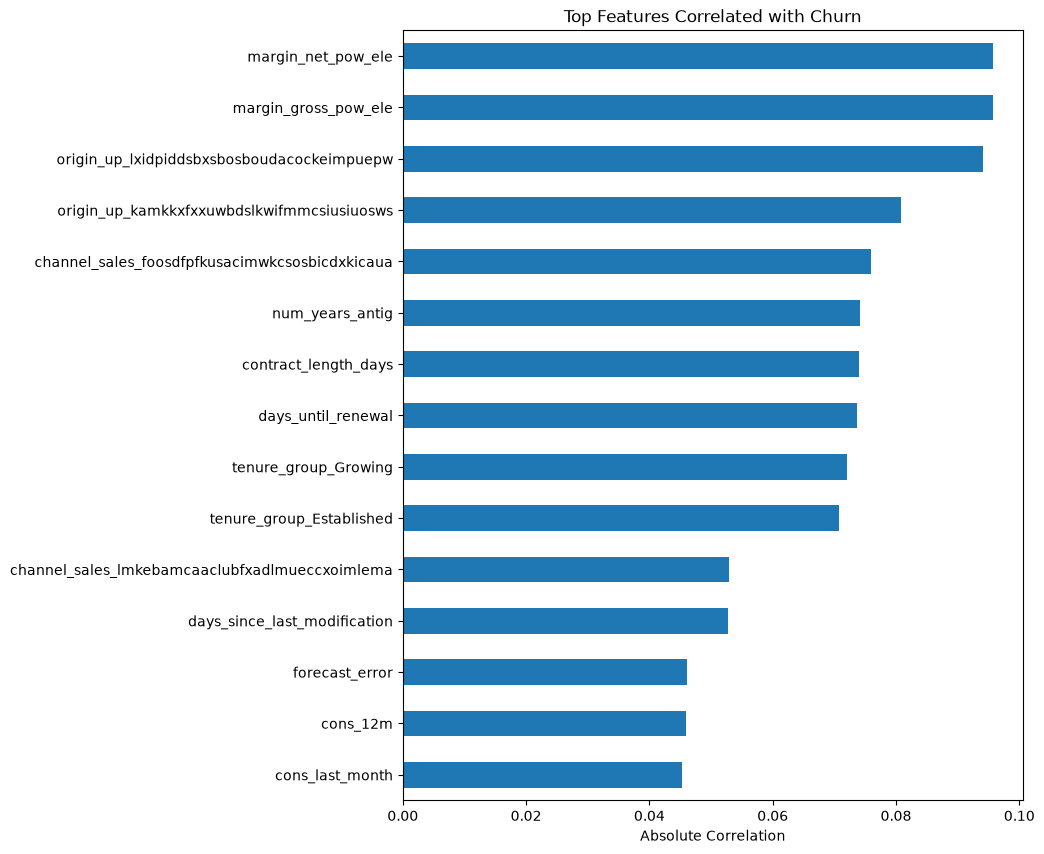

In [19]:
plt.figure(figsize=(8,10))

correlation.drop("churn").abs().sort_values().tail(15).plot(kind="barh")

plt.title("Top Features Correlated with Churn")

plt.xlabel("Absolute Correlation")

plt.show()

In [20]:
print("Final Dataset Shape")

print(df.shape)

df.head()

Final Dataset Shape
(14606, 61)


,id,cons_12m,cons_gas_12m,cons_last_month,forecast_cons_12m,forecast_cons_year,forecast_discount_energy,forecast_meter_rent_12m,forecast_price_energy_off_peak,forecast_price_energy_peak,forecast_price_pow_off_peak,has_gas,imp_cons,margin_gross_pow_ele,margin_net_pow_ele,nb_prod_act,net_margin,num_years_antig,pow_max,var_year_price_off_peak_var,var_year_price_peak_var,var_year_price_mid_peak_var,var_year_price_off_peak_fix,var_year_price_peak_fix,var_year_price_mid_peak_fix,var_year_price_off_peak,var_year_price_peak,var_year_price_mid_peak,var_6m_price_off_peak_var,var_6m_price_peak_var,var_6m_price_mid_peak_var,var_6m_price_off_peak_fix,var_6m_price_peak_fix,var_6m_price_mid_peak_fix,var_6m_price_off_peak,var_6m_price_peak,var_6m_price_mid_peak,churn,contract_length_days,days_until_renewal,days_since_last_modification,monthly_consumption_ratio,forecast_error,margin_ratio,consumption_per_product,consumption_per_power,channel_sales_epumfxlbckeskwekxbiuasklxalciiuu,channel_sales_ewpakwlliwisiwduibdlfmalxowmwpci,channel_sales_fixdbufsefwooaasfcxdxadsiekoceaa,channel_sales_foosdfpfkusacimwkcsosbicdxkicaua,channel_sales_lmkebamcaaclubfxadlmueccxoimlema,channel_sales_sddiedcslfslkckwlfkdpoeeailfpeds,channel_sales_usilxuppasemubllopkaafesmlibmsdf,origin_up_ewxeelcelemmiwuafmddpobolfuxioce,origin_up_kamkkxfxxuwbdslkwifmmcsiusiuosws,origin_up_ldkssxwpmemidmecebumciepifcamkci,origin_up_lxidpiddsbxsbosboudacockeimpuepw,origin_up_usapbepcfoloekilkwsdiboslwaxobdp,tenure_group_Growing,tenure_group_Established,tenure_group_Loyal
0,24011ae4ebbe3035111d65fa7c15bc57,0,54946,0,0.00,0,0.0,1.78,0.114481,0.098142,40.606701,t,0.00,25.44,25.44,2,678.99,3,43.648,0.000061,2.627605e-05,0.000440,1.102785,49.550703,22.022535,1.102846,4.955073e+01,22.022975,0.000131,4.100838e-05,9.084737e-04,2.086294,99.530517,44.235794,2.086425,9.953056e+01,4.423670e+01,1,1096,738,-131,0.000000,0.00,0.962179,0.0,0.000000,False,False,False,True,False,False,False,False,False,False,True,False,True,False,False
1,d29c2c54acc38ff3c0614d0a653813dd,4660,0,0,189.95,0,0.0,16.27,0.145711,0.000000,44.311378,f,0.00,16.38,16.38,1,18.89,6,13.800,0.000005,6.089453e-04,0.000000,0.006465,0.000000,0.000000,0.006470,6.089453e-04,0.000000,0.000003,1.217891e-03,0.000000e+00,0.009482,0.000000,0.000000,0.009485,1.217891e-03,0.000000e+00,0,2566,2201,2201,0.000000,-4470.05,0.942463,4660.0,314.864865,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False
2,764c75f661154dac3a6c254cd082ea7d,544,0,0,47.96,0,0.0,38.72,0.165794,0.087899,44.311378,f,0.00,28.60,28.60,1,6.60,6,13.856,0.000006,2.558511e-07,0.000000,0.007662,0.000000,0.000000,0.007668,2.558511e-07,0.000000,0.000004,9.450150e-08,0.000000e+00,0.000000,0.000000,0.000000,0.000004,9.450150e-08,0.000000e+00,0,2192,1827,1827,0.000000,-496.04,0.966216,544.0,36.618201,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False
3,bba03439a292a1e166f80264c16191cb,1584,0,0,240.04,0,0.0,19.83,0.146694,0.000000,44.311378,f,0.00,30.22,30.22,1,25.46,6,13.200,0.000005,0.000000e+00,0.000000,0.006465,0.000000,0.000000,0.006470,0.000000e+00,0.000000,0.000003,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000003,0.000000e+00,0.000000e+00,0,2192,1827,1827,0.000000,-1343.96,0.967969,1584.0,111.549296,False,False,False,False,True,False,False,False,True,False,False,False,False,True,False
4,149d57cf92fc41cf94415803a877cb4b,4425,0,526,445.75,526,0.0,131.73,0.116900,0.100015,40.606701,f,52.32,44.91,44.91,1,47.98,6,19.800,0.000015,3.552481e-06,0.000003,0.005429,0.001954,0.000869,0.005444,1.957971e-03,0.000871,0.000011,2.896760e-06,4.860000e-10,0.000000,0.000000,0.000000,0.000011,2.896760e-06,4.860000e-10,0,2245,1881,1881,1.422583,-3979.25,0.978218,4425.0,212.740385,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False


In [21]:
df.to_csv(
    "feature_engineered_data.csv",
    index=False
)

print("Feature engineered dataset saved successfully.")

Feature engineered dataset saved successfully.


# Conclusion

Several new features were engineered to better represent customer behavior, contract characteristics, pricing dynamics, and energy consumption patterns.

The following feature engineering techniques were applied:

- Converted raw date columns into duration-based features.
- Created contract and renewal duration variables.
- Generated consumption and pricing ratios.
- Calculated forecast errors.
- Created customer tenure categories.
- Encoded categorical variables for machine learning.
- Removed raw date columns after extracting useful information.

The resulting dataset is now ready for predictive modeling in the next stage of the project.